# **Child Well-being — MDS Country Projection**
**University: University of Milano-Bicocca**  
**Master's Degree: Data Science (A.Y. 2025/2026)**  
**Course: Data Science Lab**

---

**Goal**: project each OECD country into a 2D (or 3D) space using **Classical Multi-Dimensional Scaling** (cMDS / PCoA),  
starting from posetic **symmetric separation** between countries computed via Bubley-Dyer MCMC sampling.  
Countries with similar ranking behaviour end up close together; countries with very different profiles are far apart.

**Temporal comparison**: after independently computing MDS for 2015 and 2018, the two embeddings are  
aligned using **Procrustes analysis** (rotation + reflection, no scaling) so that arrows between the  
same country across years represent genuine positional shifts in the dominance space.

| Domain | 2015 dataset | 2018 dataset |
|--------|--------------|--------------|
| **Indicators** | `040_indicators_macro_dim_3_level_2015.parquet` | `040_indicators_macro_dim_3_level_2018.parquet` |
| **Public Expenditure** | `040_public_expenditure_dim_discrete_4_level_2015.parquet` | `040_public_expenditure_dim_discrete_4_level_2018.parquet` |

---

### Method: posetic Separation → cMDS → Procrustes

**Step 1 — Symmetric Separation dissimilarity**  
For a poset $P$ with $n$ elements, the symmetric separation between elements $i$ and $j$ is:
$$\text{Sep}(i,j) = \mathbb{E}_{\sigma \sim \text{LE}(P)}\bigl[|\sigma(i) - \sigma(j)|\bigr]$$
the expected absolute rank difference, averaged over all linear extensions via **Bubley-Dyer MCMC** (50 000 samples).  
Normalised to $[0,1]$ by dividing by $n-1$, this gives a smooth, Euclidean-like dissimilarity:
$$D(i,j) = \frac{\text{Sep}(i,j)}{n-1}$$
Pairs of countries that tend to receive similar ranks across all compatible total orders → small $D$;  
pairs that are typically far apart in rank (or are incomparable) → large $D$.

**Step 2 — Classical MDS**  
Double-centering of $D^2$ yields the Gram matrix $B$; its top eigenvectors give the 2D/3D coordinates.
$$B = -\frac{1}{2} H D^{(2)} H, \quad H = I - \frac{1}{n}\mathbf{1}\mathbf{1}^T$$

**Step 3 — Procrustes alignment**  
Both embeddings are centered and scaled to unit Frobenius norm, then the 2018 embedding is  
rotated/reflected to best match the 2015 embedding. Arrows then show genuine positional change.

In [18]:
import sys; sys.path.insert(0, "..")

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes

import poset as P

pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)

polars.config.Config

---
## 1. Load data & build POSets

In [19]:
DOMAINS = {
    "indicators": {
        2015: "../data/040_indicators_macro_dim_3_level_2015.parquet",
        2018: "../data/040_indicators_macro_dim_3_level_2018.parquet",
        "label": "Child Outcome Indicators (macro-dim, 3 levels)",
    },
    "expenditure": {
        2015: "../data/040_public_expenditure_dim_discrete_4_level_2015.parquet",
        2018: "../data/040_public_expenditure_dim_discrete_4_level_2018.parquet",
        "label": "Public Expenditure (4 levels)",
    },
}

ID_COLS = {"REF_AREA", "TIME_PERIOD"}


def load_all_posets(domains: dict) -> tuple[dict, list]:
    """Load all posets and return (results_dict, country_list)."""
    results = {}
    for domain, meta in domains.items():
        results[domain] = {}
        for year in (2015, 2018):
            df = pl.read_parquet(meta[year])
            ind_cols = [c for c in df.columns if c not in ID_COLS]
            res = P.poset_from_polars(
                df, col1="REF_AREA", indicator_cols=ind_cols,
                higher_is_better=True, dominance_mode="certain_or_possible",
            )
            results[domain][year] = res
            print(f"[{domain} {year}]  {len(res['elements'])} countries | "
                  f"indicators: {ind_cols}")

    countries = results["indicators"][2015]["elements"]
    print(f"\nCountries ({len(countries)}): {countries}")
    return results, countries

results, COUNTRIES = load_all_posets(DOMAINS)

[indicators 2015]  16 countries | indicators: ['material_protection', 'health_prevention', 'education_skills', 'social_wellbeing']
[indicators 2018]  16 countries | indicators: ['material_protection', 'health_prevention', 'education_skills', 'social_wellbeing']
[expenditure 2015]  16 countries | indicators: ['C2_housing_culture', 'C3_public_health', 'C4_education_childcare', 'C5_environment']
[expenditure 2018]  16 countries | indicators: ['C2_housing_culture', 'C3_public_health', 'C4_education_childcare', 'C5_environment']

Countries (16): ['SWE', 'LTU', 'LVA', 'EST', 'GBR', 'FRA', 'LUX', 'AUT', 'ESP', 'PRT', 'ITA', 'SVN', 'POL', 'CZE', 'SVK', 'HUN']


---
## 2. Core functions

In [20]:
def separation_dissimilarity(
    result: dict,
    ref_elements: list,
    n_samples: int = 50_000,
    seed: int = 42,
) -> np.ndarray:
    """
    Symmetric posetic separation dissimilarity matrix.

    D[i,j] = E[|rank(i) - rank(j)|] / (n - 1)  in [0, 1]

    Averaged over linear extensions via Bubley-Dyer MCMC,
    reindexed to ref_elements order.
    """
    poset = result["poset_certain"]
    elements = result["elements"]
    n = poset.n

    gen = P.BuildBubleyDyerSeparationGenerator(poset, seed, "symmetric")
    sep_result = gen.update(n=n_samples)
    sym = sep_result["symmetric"]

    perm = [elements.index(e) for e in ref_elements]
    D = sym[np.ix_(perm, perm)] / (n - 1)
    np.fill_diagonal(D, 0.0)
    return (D + D.T) / 2


def align_procrustes(
    X_ref: np.ndarray,
    X_target: np.ndarray,
    scale: bool = False,
) -> tuple[np.ndarray, np.ndarray, float]:
    """
    Procrustes alignment of X_target onto X_ref.

    Parameters
    ----------
    X_ref : (n, d) reference coordinates (e.g. 2015)
    X_target : (n, d) target coordinates (e.g. 2018)
    scale : bool
        If False (default): rotation + reflection only.
        If True: also applies optimal scaling (like scipy.spatial.procrustes).

    Returns
    -------
    X_ref_c : centered reference
    X_target_aligned : aligned target
    disparity : sum of squared differences after alignment
    """
    # Center both
    X_ref_c = X_ref - X_ref.mean(axis=0)
    X_target_c = X_target - X_target.mean(axis=0)

    # Optimal rotation/reflection
    R, _ = orthogonal_procrustes(X_target_c, X_ref_c)
    X_target_rot = X_target_c @ R

    if scale:
        # Optimal scaling factor: s = trace(X_ref' @ X_target_rot) / trace(X_target_rot' @ X_target_rot)
        s = np.trace(X_ref_c.T @ X_target_rot) / np.trace(X_target_rot.T @ X_target_rot)
        X_target_rot = X_target_rot * s

    disparity = float(np.sum((X_ref_c - X_target_rot) ** 2))
    return X_ref_c, X_target_rot, disparity

def classical_mds(D: np.ndarray, n_components: int = 2) -> tuple:
    """
    Classical MDS (Principal Coordinate Analysis).

    Returns (coords, eigenvalues, explained_variance_ratio).
    """
    n = D.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * H @ (D ** 2) @ H
    B = (B + B.T) / 2

    vals, vecs = np.linalg.eigh(B)
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]

    pos_sum = max(vals[vals > 0].sum(), 1e-12)
    explained = vals[:n_components] / pos_sum
    coords = vecs[:, :n_components] * np.sqrt(np.maximum(vals[:n_components], 0))
    return coords, vals, explained


def mds_stress(D: np.ndarray, coords: np.ndarray) -> float:
    """Kruskal stress-1."""
    D_hat = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))
    return float(np.sqrt(np.sum((D - D_hat) ** 2) / np.sum(D ** 2)))

print("Functions defined.")

Functions defined.


---
## 3. Compute MDS embeddings & Procrustes alignment

In [21]:
N_SAMPLES = 50_000

def compute_all_mds(
    results: dict,
    domains: dict,
    countries: list,
    n_samples: int = 50_000,
) -> tuple[dict, dict]:
    """Compute MDS for all domains/years and Procrustes-align 2015→2018."""
    mds = {}
    for domain in domains:
        mds[domain] = {}
        for year in (2015, 2018):
            print(f"[{domain} {year}]  separation ({n_samples:,} samples)...",
                  end=" ", flush=True)
            D = separation_dissimilarity(results[domain][year], countries,
                                         n_samples=n_samples)
            c2d, vals, e2d = classical_mds(D, 2)
            c3d, _, _ = classical_mds(D, 3)
            stress = mds_stress(D, c2d)
            mds[domain][year] = {
                "D": D, "2d": c2d, "3d": c3d,
                "explained": e2d, "stress": stress, "eigenvalues": vals,
            }
            print(f"explained: {e2d.sum()*100:.1f}% | stress-1: {stress:.3f}")

    aligned = {}
    for domain in domains:
        X15_2d, X18_2d, d2d = X15_2d, X18_2d, d2d = align_procrustes(mds[domain][2015]["2d"],mds[domain][2018]["2d"],scale=False,)
        X15_3d, X18_3d, d3d = align_procrustes(mds[domain][2015]["3d"], mds[domain][2018]["3d"], scale=False)
        aligned[domain] = {
            "2d": (X15_2d, X18_2d, d2d),
            "3d": (X15_3d, X18_3d, d3d),
        }
        print(f"\n[{domain}] Procrustes disparity  2D: {d2d:.4f}  3D: {d3d:.4f}")

    return mds, aligned

mds, aligned = compute_all_mds(results, DOMAINS, COUNTRIES, N_SAMPLES)

[indicators 2015]  separation (50,000 samples)... explained: 87.5% | stress-1: 0.133
[indicators 2018]  separation (50,000 samples)... explained: 83.6% | stress-1: 0.167
[expenditure 2015]  separation (50,000 samples)... explained: 68.3% | stress-1: 0.276
[expenditure 2018]  separation (50,000 samples)... explained: 82.0% | stress-1: 0.190

[indicators] Procrustes disparity  2D: 1.6282  3D: 1.6939

[expenditure] Procrustes disparity  2D: 0.5507  3D: 0.5758


---
## 4. Plots

In [22]:
def _shorten(label: str, sep: str = "_") -> str:
    return label.split(sep)[0] if sep in label else label


def plot_movement_2d(
    X15: np.ndarray,
    X18: np.ndarray,
    labels: list,
    title: str,
    expl: np.ndarray | None = None,
    disparity: float | None = None,
    figsize: tuple = (12, 9),
    color_15: str = "#2980b9",
    color_18: str = "#c0392b",
    save_path: str | None = None,
    dpi: int = 200,
):
    """2D MDS movement plot with displacement-coloured arrows."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.axhline(0, color="#dee2e6", lw=0.8, zorder=0)
    ax.axvline(0, color="#dee2e6", lw=0.8, zorder=0)

    displacements = np.linalg.norm(X18 - X15, axis=1)
    max_disp = max(displacements.max(), 1e-12)
    cmap = plt.colormaps["RdYlGn_r"]

    # Arrows
    for i in range(len(labels)):
        ax.annotate(
            "", xy=X18[i], xytext=X15[i],
            arrowprops=dict(
                arrowstyle="-|>", lw=1.8, mutation_scale=12,
                color=cmap(displacements[i] / max_disp),
            ),
            zorder=3,
        )

    # Points
    short = [_shorten(l) for l in labels]
    ax.scatter(X15[:, 0], X15[:, 1], c=color_15, s=160, zorder=5,
               edgecolors="white", linewidths=1.5, marker="o", label="2015")
    ax.scatter(X18[:, 0], X18[:, 1], c=color_18, s=160, zorder=5,
               edgecolors="white", linewidths=1.5, marker="D", label="2018")

    # Labels at 2015 position
    for i, lbl in enumerate(short):
        ax.annotate(lbl, X15[i], fontsize=8, color="#1a5276",
                    xytext=(5, 5), textcoords="offset points", zorder=6)

    # Axis labels with explained variance
    dim1 = f"MDS dim 1 ({expl[0]*100:.1f}%)" if expl is not None else "MDS dim 1"
    dim2 = f"MDS dim 2 ({expl[1]*100:.1f}%)" if expl is not None else "MDS dim 2"
    ax.set_xlabel(dim1, fontsize=10)
    ax.set_ylabel(dim2, fontsize=10)

    subtitle = f"Procrustes disparity: {disparity:.4f}" if disparity is not None else ""
    ax.set_title(f"{title}\n{subtitle}", fontsize=12, fontweight="bold")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, max_disp))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label("Displacement magnitude", fontsize=9)

    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.15)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    return fig, ax


def plot_movement_3d(
    X15: np.ndarray,
    X18: np.ndarray,
    labels: list,
    title: str,
    figsize: tuple = (13, 10),
    color_15: str = "#2980b9",
    color_18: str = "#c0392b",
    save_path: str | None = None,
    dpi: int = 200,
):
    """3D MDS movement plot."""
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")
    short = [_shorten(l) for l in labels]

    for i in range(len(labels)):
        ax.plot(
            [X15[i, 0], X18[i, 0]],
            [X15[i, 1], X18[i, 1]],
            [X15[i, 2], X18[i, 2]],
            c="#95a5a6", lw=1.0, alpha=0.6,
        )

    ax.scatter(*X15.T, c=color_15, s=100, label="2015",
               depthshade=True, edgecolors="white", linewidths=0.8)
    ax.scatter(*X18.T, c=color_18, s=100, label="2018", marker="^",
               depthshade=True, edgecolors="white", linewidths=0.8)

    for i, lbl in enumerate(short):
        ax.text(X15[i, 0], X15[i, 1], X15[i, 2], f" {lbl}",
                fontsize=7, color=color_15)

    ax.set_xlabel("Dim 1", fontsize=9)
    ax.set_ylabel("Dim 2", fontsize=9)
    ax.set_zlabel("Dim 3", fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    return fig, ax


def plot_displacement_bars(
    aligned: dict,
    domains: dict,
    countries: list,
    figsize: tuple = (16, 6),
    save_path: str | None = None,
    dpi: int = 200,
):
    """Side-by-side displacement bar charts for all domains."""
    n_domains = len(domains)
    fig, axes = plt.subplots(1, n_domains, figsize=figsize, sharey=False)
    if n_domains == 1:
        axes = [axes]

    cmap = plt.colormaps["RdYlGn_r"]
    short = [_shorten(c) for c in countries]

    for ax, domain in zip(axes, domains):
        X15, X18, _ = aligned[domain]["2d"]
        disps = np.linalg.norm(X18 - X15, axis=1)
        order = np.argsort(disps)[::-1]

        names = [short[i] for i in order]
        vals = disps[order]
        max_d = max(vals.max(), 1e-12)
        colors = [cmap(d / max_d) for d in vals]

        bars = ax.bar(names, vals, color=colors, edgecolor="white", linewidth=0.8)

        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_d * 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7,
            )

        ax.set_title(domains[domain]["label"], fontsize=11, fontweight="bold")
        ax.set_ylabel("Displacement (Procrustes space)", fontsize=9)
        ax.tick_params(axis="x", rotation=40, labelsize=8)
        ax.grid(axis="y", alpha=0.2)

    fig.suptitle("Country displacement 2015 → 2018 in MDS space",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    return fig, axes


def plot_scree(
    mds: dict,
    domains: dict,
    figsize: tuple = (14, 10),
    save_path: str | None = None,
    dpi: int = 200,
):
    """Scree plots for all domain/year combinations."""
    fig, axes = plt.subplots(len(domains), 2, figsize=figsize)

    for row, domain in enumerate(domains):
        for col, year in enumerate((2015, 2018)):
            ax = axes[row, col]
            vals = mds[domain][year]["eigenvalues"]
            pos_vals = vals[vals > 0]
            frac = pos_vals / pos_vals.sum()
            cum = np.cumsum(frac) * 100
            dims = np.arange(1, len(pos_vals) + 1)

            ax.bar(dims, frac, color="#3498db", alpha=0.7,
                   edgecolor="white", label="Individual")

            ax2 = ax.twinx()
            ax2.plot(dims, cum, "o-", color="#e74c3c", lw=2, ms=5,
                     label="Cumulative %")
            ax2.axhline(90, color="#e74c3c", lw=0.8, ls="--", alpha=0.6)
            ax2.set_ylabel("Cumulative (%)", fontsize=9, color="#e74c3c")
            ax2.tick_params(axis="y", colors="#e74c3c")
            ax2.set_ylim(0, 105)

            ax.set_xlabel("Dimension", fontsize=9)
            ax.set_ylabel("Variance fraction", fontsize=9)
            ax.set_title(f"{domain.capitalize()} — {year}",
                         fontsize=11, fontweight="bold")
            ax.set_xticks(dims)
            ax.grid(axis="y", alpha=0.2)

    fig.suptitle("Scree plots — MDS eigenvalue decomposition",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    return fig, axes

Arrows connect each country's **2015** position (circle, blue) to its **2018** position (diamond, red)  
in the Procrustes-aligned MDS space.  
Longer arrows = larger shift in the dominance structure between the two years.

---

### 4.1 Child Outcome indicators and Public Expenditure

#### 4.1.1 2D Trajectories 2015 vs 2018

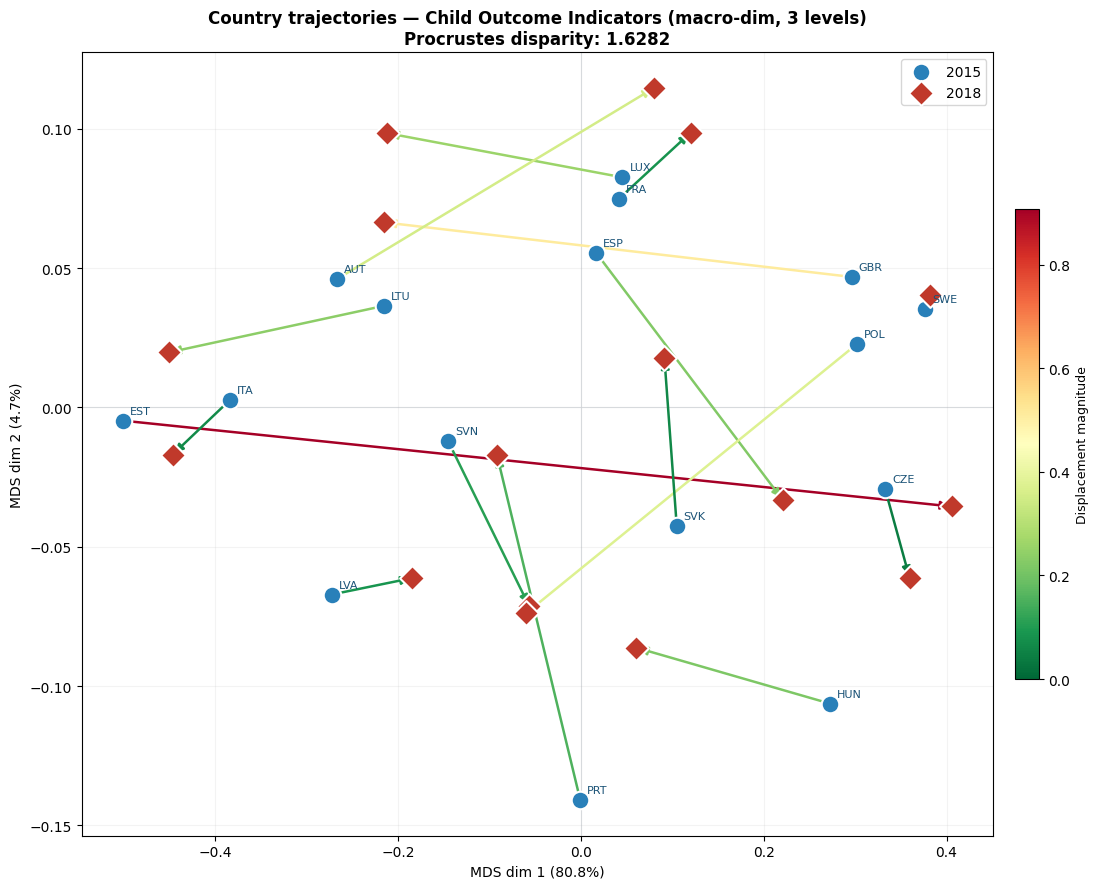

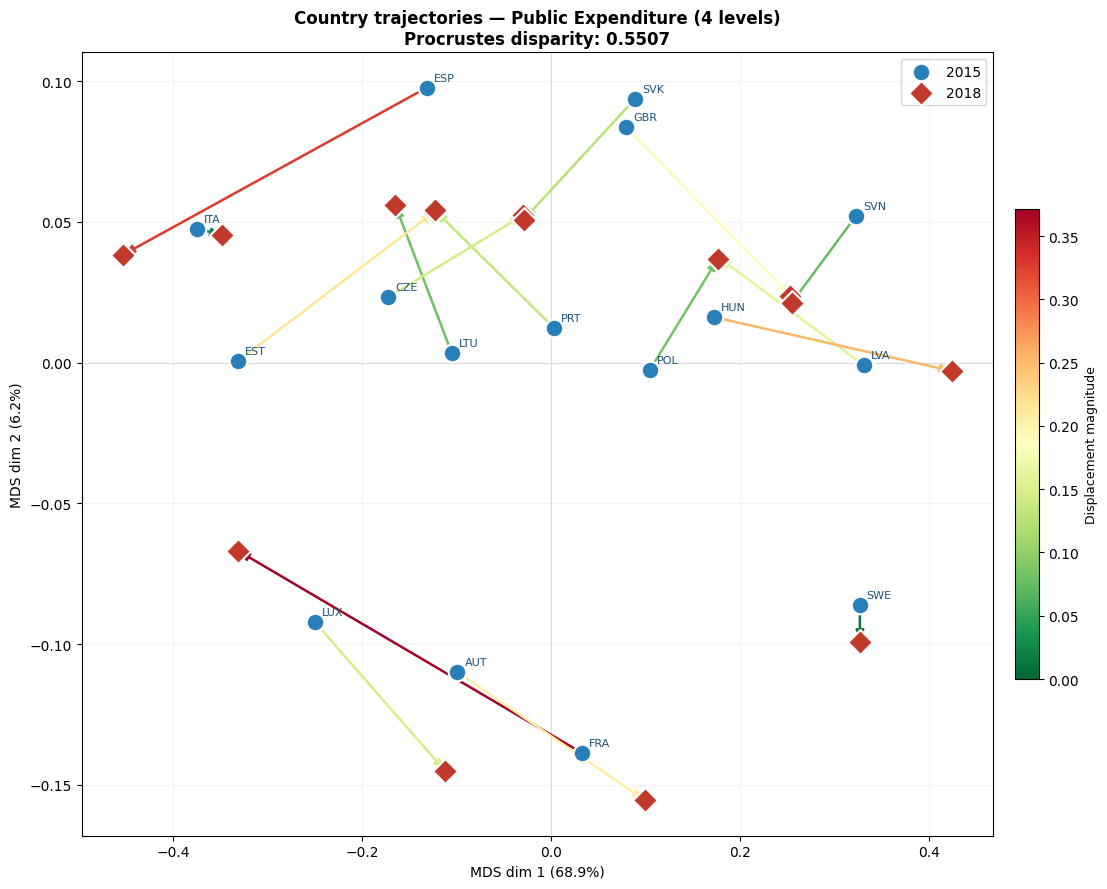

In [23]:
# 2D movement plots
for domain in DOMAINS:
    X15, X18, disp = aligned[domain]["2d"]
    expl_avg = (mds[domain][2015]["explained"] + mds[domain][2018]["explained"]) / 2
    plot_movement_2d(
        X15, X18, COUNTRIES,
        title=f"Country trajectories — {DOMAINS[domain]['label']}",
        expl=expl_avg, disparity=disp,
    )

#### 4.1.2. 3D Trajectories 2015 vs 2018

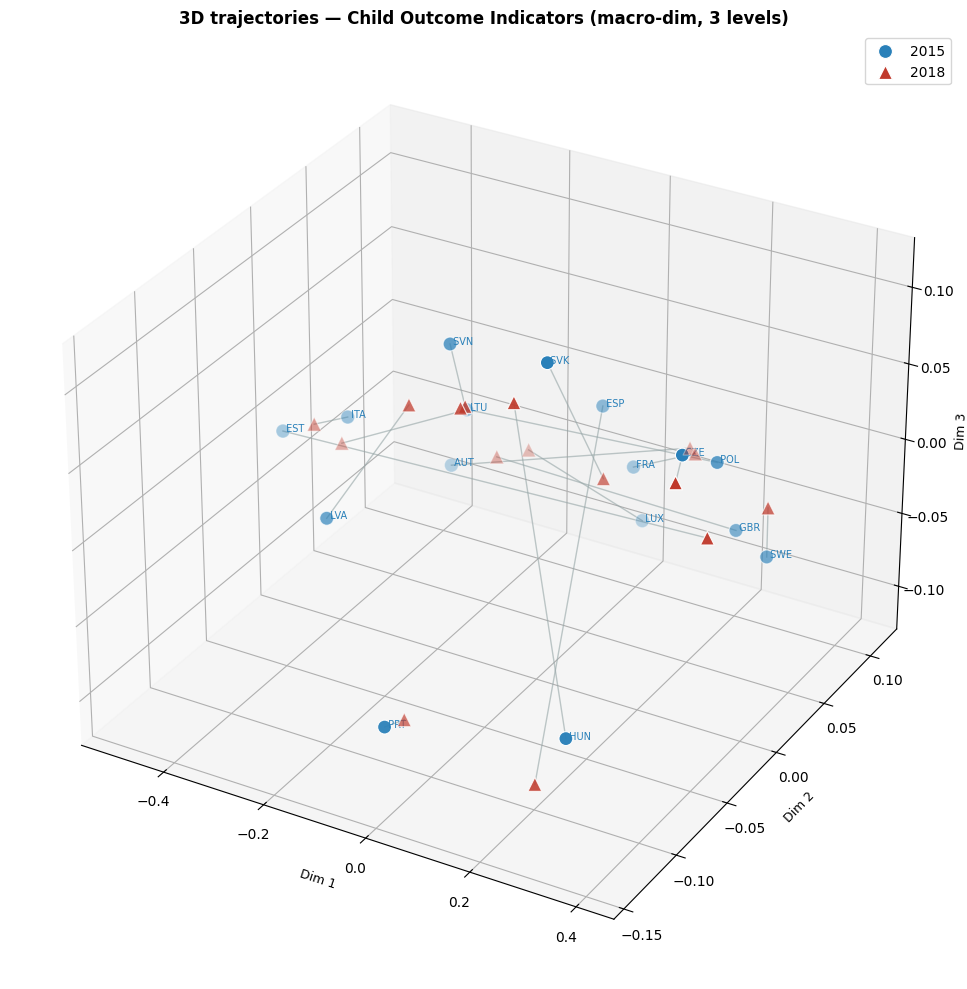

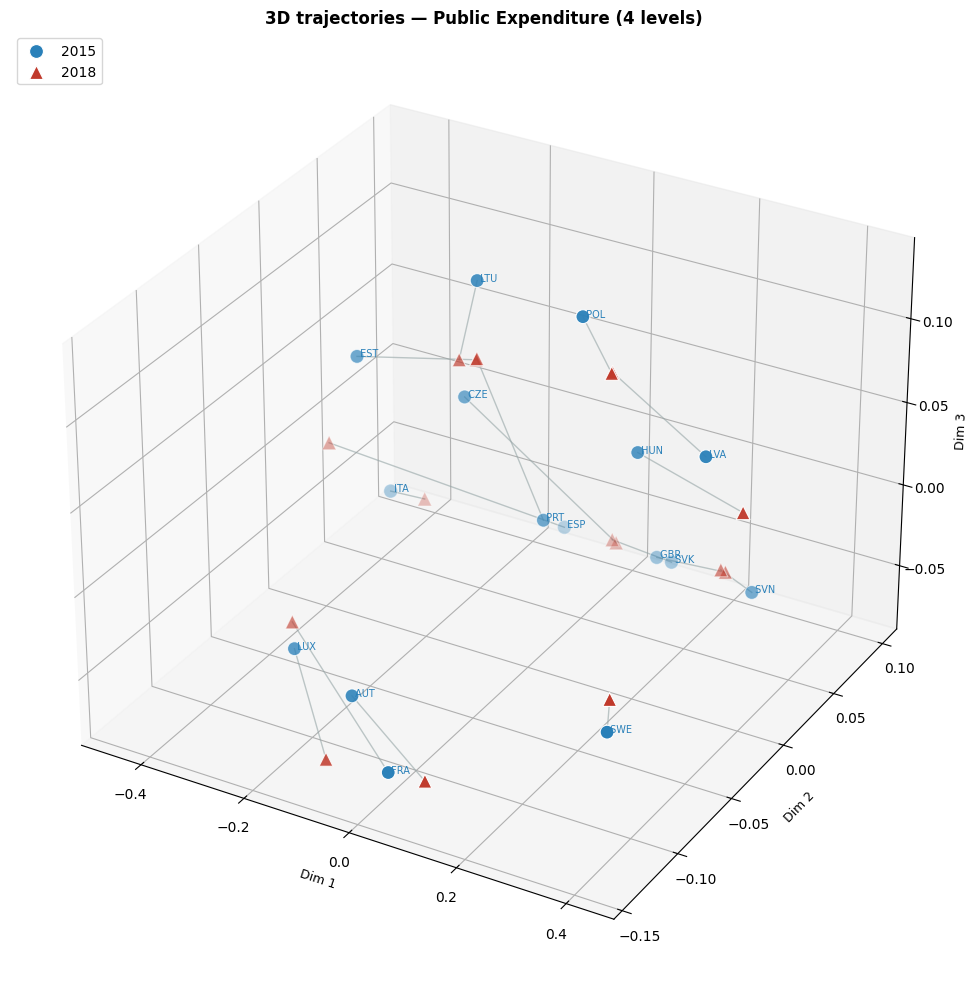

In [24]:
# 3D movement plots
for domain in DOMAINS:
    X15_3d, X18_3d, _ = aligned[domain]["3d"]
    plot_movement_3d(
        X15_3d, X18_3d, COUNTRIES,
        title=f"3D trajectories — {DOMAINS[domain]['label']}",
    )

#### 4.1.3. Country displacement 2015 vs 2018

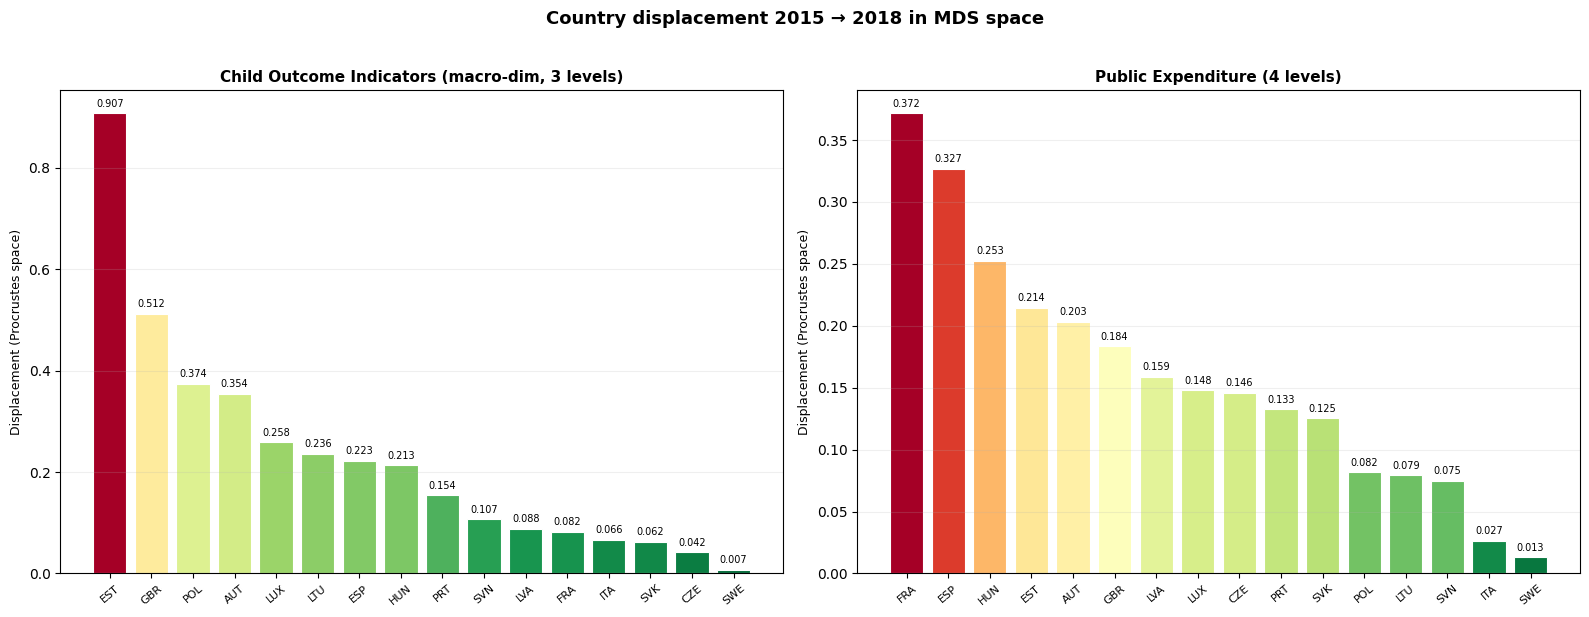

(<Figure size 1600x600 with 2 Axes>,
 array([<Axes: title={'center': 'Child Outcome Indicators (macro-dim, 3 levels)'}, ylabel='Displacement (Procrustes space)'>,
        <Axes: title={'center': 'Public Expenditure (4 levels)'}, ylabel='Displacement (Procrustes space)'>],
       dtype=object))

In [25]:
# Displacement bars
plot_displacement_bars(aligned, DOMAINS, COUNTRIES)

### 4.2 Scree plots — eigenvalue explained variance

How many dimensions are needed to faithfully represent the dominance structure?  
The elbow in the scree plot indicates the optimal number of MDS components.

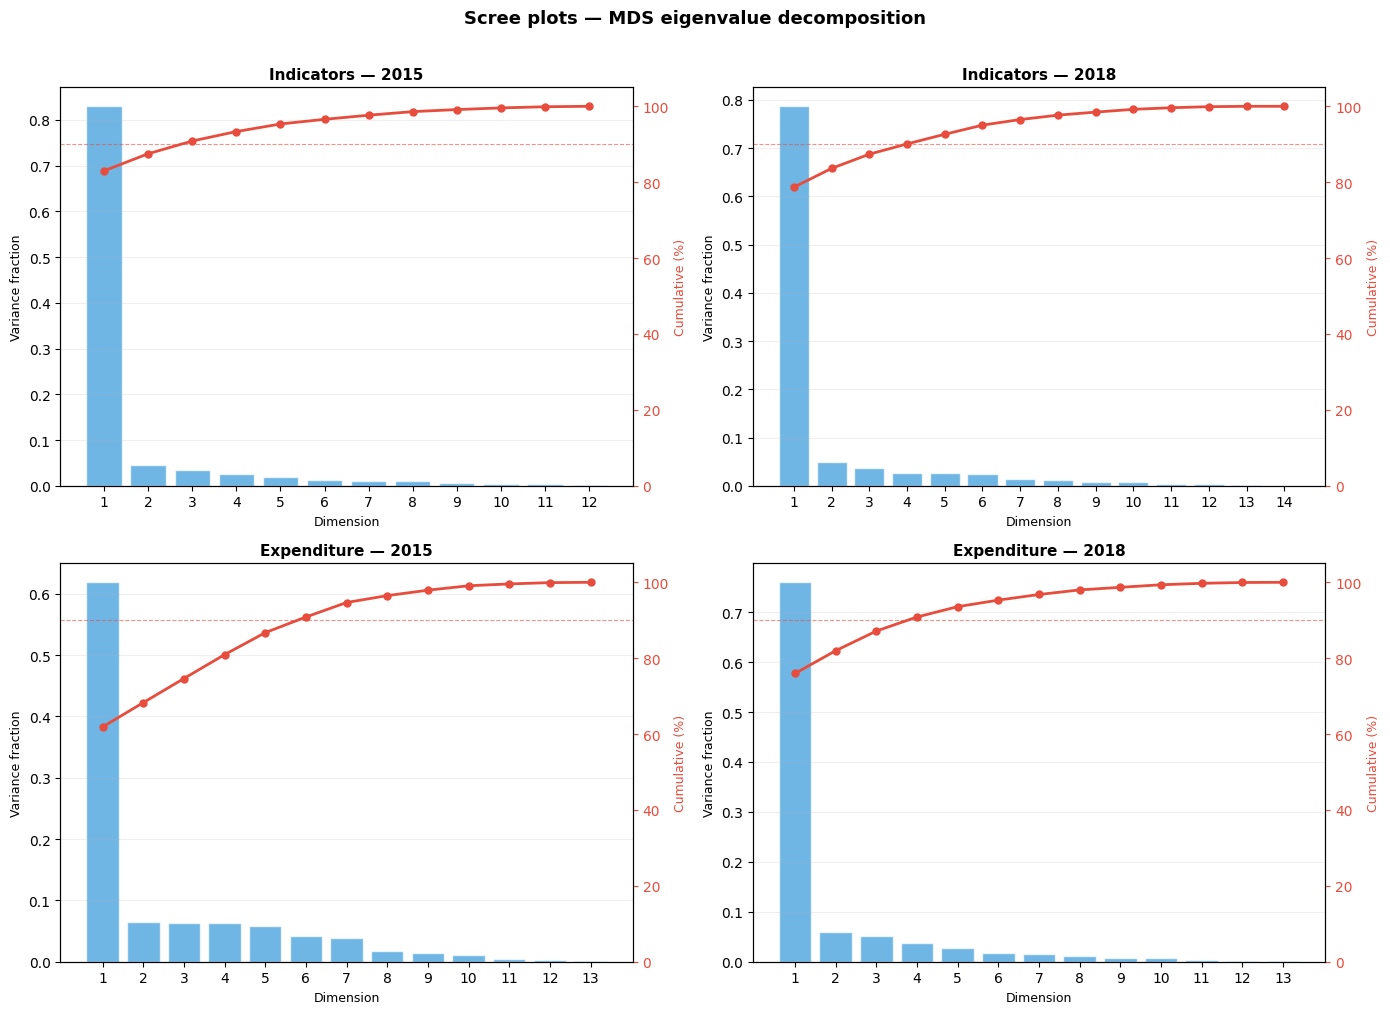

(<Figure size 1400x1000 with 8 Axes>,
 array([[<Axes: title={'center': 'Indicators — 2015'}, xlabel='Dimension', ylabel='Variance fraction'>,
         <Axes: title={'center': 'Indicators — 2018'}, xlabel='Dimension', ylabel='Variance fraction'>],
        [<Axes: title={'center': 'Expenditure — 2015'}, xlabel='Dimension', ylabel='Variance fraction'>,
         <Axes: title={'center': 'Expenditure — 2018'}, xlabel='Dimension', ylabel='Variance fraction'>]],
       dtype=object))

In [26]:
# Scree plots
plot_scree(mds, DOMAINS)

### 4.3 Summary — displacement magnitudes

How much did each country move in the Procrustes-aligned MDS space?  
A large displacement means the country's relative position in the dominance structure changed significantly.

In [27]:
# Displacement summary table
summary_rows = []
for domain in DOMAINS:
    X15, X18, _ = aligned[domain]["2d"]
    disps = np.linalg.norm(X18 - X15, axis=1)
    for i, country in enumerate(COUNTRIES):
        summary_rows.append({
            "country": _shorten(country),
            "domain": domain,
            "displacement": round(float(disps[i]), 4),
        })

In [28]:
summary_df = pl.DataFrame(summary_rows)
display(summary_df.sort(["domain", "displacement"], descending=[False, True]))

country,domain,displacement
str,str,f64
"""FRA""","""expenditure""",0.3716
"""ESP""","""expenditure""",0.3266
"""HUN""","""expenditure""",0.2526
"""EST""","""expenditure""",0.2144
"""AUT""","""expenditure""",0.2033
"""GBR""","""expenditure""",0.1836
"""LVA""","""expenditure""",0.1587
"""LUX""","""expenditure""",0.1479
"""CZE""","""expenditure""",0.146


*This notebook is licensed under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).*